In [1]:
import os
import pysam
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# 1. Define Paths
BASE_DIR = os.path.expanduser('~/celltor')
RAW_DATA_DIR = os.path.join(BASE_DIR, 'data', 'raw')
VCF_PATH = os.path.join(RAW_DATA_DIR, 'ALL.chr22.phase3_shapeit2_mvncall_integrated_v5b.20130502.genotypes.vcf.gz')
PANEL_PATH = os.path.join(RAW_DATA_DIR, 'integrated_call_samples_v3.20130502.ALL.panel')

# 2. Refactored Extraction Function
def extract_genomic_features(vcf_path, panel_path, max_snps=1000):
    print(f"Extracting {max_snps} SNPs. This may take a moment...")
    
    afr_subs = {'YRI', 'LWK', 'GWD', 'MSL', 'ESN', 'ACB', 'ASW'}
    eur_subs = {'CEU', 'TSI', 'FIN', 'GBR', 'IBS'}
    
    panel_df = pd.read_csv(panel_path, sep='\t', usecols=['sample', 'pop'])
    sample_to_pop = {row['sample']: 'AFR' if row['pop'] in afr_subs else 'EUR' 
                     for _, row in panel_df.iterrows() if row['pop'] in afr_subs | eur_subs}
    
    genotype_data = {'sample': [], 'pop': []}
    vcf_in = pysam.VariantFile(vcf_path)
    valid_samples = [s for s in vcf_in.header.samples if s in sample_to_pop]
    
    for sample in valid_samples:
        genotype_data['sample'].append(sample)
        genotype_data['pop'].append(sample_to_pop[sample])
        
    snps_extracted = 0
    for record in vcf_in.fetch():
        if snps_extracted >= max_snps:
            break
        if record.alts and len(record.alts) == 1:
            snp_name = f"{record.chrom}_{record.pos}_{record.ref}_{record.alts[0]}"
            if snp_name in genotype_data:
                continue
            
            genotype_data[snp_name] = []
            for sample in valid_samples:
                gt = record.samples[sample]['GT']
                gt_val = 0 if gt[0] is None or gt[1] is None else sum(gt)
                genotype_data[snp_name].append(gt_val)
                
            snps_extracted += 1
            
    vcf_in.close()
    return pd.DataFrame(genotype_data)

# 3. Execute Extraction for Phase 2 (Scaling to 3000 SNPs)
df_3000 = extract_genomic_features(VCF_PATH, PANEL_PATH, max_snps=3000)

print(f"\nPhase 2 Extraction Complete!")
print(f"New Dataset Shape: {df_3000.shape} (Samples x [Metadata + 3000 SNPs])")

Extracting 3000 SNPs. This may take a moment...

Phase 2 Extraction Complete!
New Dataset Shape: (1164, 3002) (Samples x [Metadata + 3000 SNPs])


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import xgboost as xgb

# 1. Prepare Features and Labels
X = df_3000.drop(columns=['sample', 'pop']).values
y_raw = df_3000['pop']

le = LabelEncoder()
y = le.fit_transform(y_raw)
print(f"Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}\n")

# 2. Setup 5-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionaries to store results across folds
cv_results = {
    'Logistic Regression': {'acc': [], 'tpr_gap': []},
    'Random Forest': {'acc': [], 'tpr_gap': []},
    'XGBoost': {'acc': [], 'tpr_gap': []}
}

print("Starting 5-Fold Cross Validation (3000 SNPs). This will take a moment...\n")

fold = 1
for train_idx, test_idx in skf.split(X, y):
    print(f"Training Fold {fold}/5...")
    
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    
    # Scale the data (fit on train, transform both)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # --- Logistic Regression ---
    lr = LogisticRegression(max_iter=3000, random_state=42)
    lr.fit(X_train_scaled, y_train)
    lr_preds = lr.predict(X_test_scaled)
    
    lr_cm = confusion_matrix(y_test, lr_preds)
    lr_recall = lr_cm.diagonal() / lr_cm.sum(axis=1)
    cv_results['Logistic Regression']['acc'].append(accuracy_score(y_test, lr_preds))
    cv_results['Logistic Regression']['tpr_gap'].append(abs(lr_recall[0] - lr_recall[1]))

    # --- Random Forest ---
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train_scaled, y_train)
    rf_preds = rf.predict(X_test_scaled)
    
    rf_cm = confusion_matrix(y_test, rf_preds)
    rf_recall = rf_cm.diagonal() / rf_cm.sum(axis=1)
    cv_results['Random Forest']['acc'].append(accuracy_score(y_test, rf_preds))
    cv_results['Random Forest']['tpr_gap'].append(abs(rf_recall[0] - rf_recall[1]))

    # --- XGBoost ---
    # use_label_encoder=False silences a deprecation warning
    xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)
    xgb_model.fit(X_train_scaled, y_train)
    xgb_preds = xgb_model.predict(X_test_scaled)
    
    xgb_cm = confusion_matrix(y_test, xgb_preds)
    xgb_recall = xgb_cm.diagonal() / xgb_cm.sum(axis=1)
    cv_results['XGBoost']['acc'].append(accuracy_score(y_test, xgb_preds))
    cv_results['XGBoost']['tpr_gap'].append(abs(xgb_recall[0] - xgb_recall[1]))
    
    fold += 1

# 3. Print Final Averaged Results
print("\n========================================")
print(" 5-FOLD CROSS-VALIDATION RESULTS (3000 SNPs) ")
print("========================================")
for model_name, metrics in cv_results.items():
    avg_acc = np.mean(metrics['acc'])
    avg_gap = np.mean(metrics['tpr_gap'])
    print(f"{model_name}:")
    print(f"  -> Mean Accuracy: {avg_acc:.4f}")
    print(f"  -> Mean TPR Gap:  {avg_gap:.4f}")
    print("-" * 40)

Class mapping: {'AFR': np.int64(0), 'EUR': np.int64(1)}

Starting 5-Fold Cross Validation (3000 SNPs). This will take a moment...

Training Fold 1/5...


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Training Fold 2/5...


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Training Fold 3/5...


...

Training Fold 4/5...


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")


Training Fold 5/5...


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



 5-FOLD CROSS-VALIDATION RESULTS (3000 SNPs) 
Logistic Regression:
  -> Mean Accuracy: 0.9837
  -> Mean TPR Gap:  0.0253
----------------------------------------
Random Forest:
  -> Mean Accuracy: 0.9613
  -> Mean TPR Gap:  0.0177
----------------------------------------
XGBoost:
  -> Mean Accuracy: 0.9570
  -> Mean TPR Gap:  0.0263
----------------------------------------


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Initiating Heavy Computation: Hyperparameter Tuning & SHAP Analysis...
Your CPU fans might start spinning up now.

1. Running Randomized Grid Search (Training ~150 XGBoost models)...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/home/chanchan/miniconda3/envs/celltor/lib/python3.10/site-packages/xgboost/sklearn.py:1395: UserWarning: `use_label_encoder` is deprecated in 1.7.0.
  warnings.warn("`use_label_encoder` is deprecated in 1.7.0.")



Optimization Complete!
Best Parameters Found: {'subsample': 1.0, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 0.8}

2. Computing SHAP values (Game Theory Feature Importance)...
This requires intense matrix calculations...
SHAP Computation Complete! Rendering advanced visualizations...



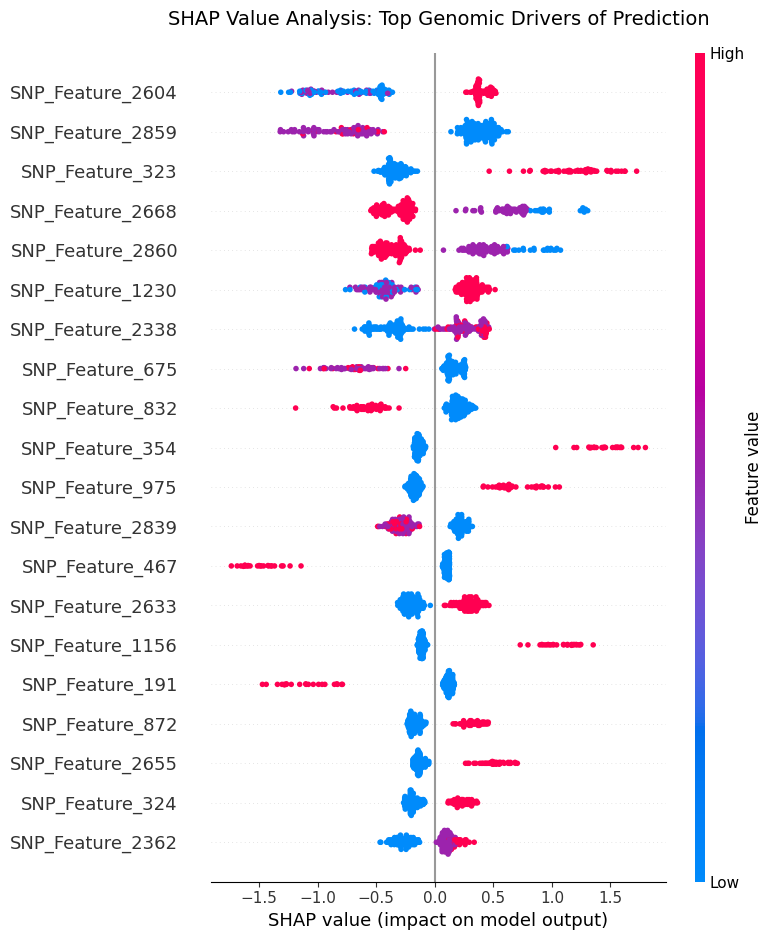

In [3]:
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import RandomizedSearchCV

print("Initiating Heavy Computation: Hyperparameter Tuning & SHAP Analysis...")
print("Your CPU fans might start spinning up now.\n")

# ==========================================
# 1. EXHAUSTIVE HYPERPARAMETER TUNING
# ==========================================
# Instead of 1 model, we will search through hundreds of combinations
# using 3-Fold Cross Validation.

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.5, 1]
}

# Base model
xgb_base = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1)

# Randomized Search (Will train ~150 different models to find the best one)
print("1. Running Randomized Grid Search (Training ~150 XGBoost models)...")
random_search = RandomizedSearchCV(
    estimator=xgb_base, 
    param_distributions=param_grid, 
    n_iter=50,          # Number of parameter settings that are sampled
    scoring='accuracy', 
    cv=3,               # 3-Fold CV for each parameter setting
    verbose=1,          # Will print progress so you can watch it work
    random_state=42,
    n_jobs=-1           # Use all available CPU cores
)

# FIRE UP THE CPU
random_search.fit(X_train_scaled, y_train)

print(f"\nOptimization Complete!")
print(f"Best Parameters Found: {random_search.best_params_}")

# Extract the absolute best model from the search
best_xgb = random_search.best_estimator_

# ==========================================
# 2. EXPLAINABLE AI (SHAP VALUE COMPUTATION)
# ==========================================
# This calculates the exact impact of every single one of the 3000 SNPs
# This is computationally highly expensive.

print("\n2. Computing SHAP values (Game Theory Feature Importance)...")
print("This requires intense matrix calculations...")

# Create the SHAP explainer
explainer = shap.TreeExplainer(best_xgb)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_scaled)

print("SHAP Computation Complete! Rendering advanced visualizations...\n")

# ==========================================
# 3. RENDER THE ADVANCED AI PLOTS
# ==========================================
# This plot will show the top 20 exact SNPs that the AI uses to determine ancestry
plt.figure(figsize=(12, 8))
plt.title("SHAP Value Analysis: Top Genomic Drivers of Prediction", fontsize=14, pad=20)
# We don't have the exact SNP names in this array format, so we use indices
feature_names = [f"SNP_Feature_{i}" for i in range(X_train_scaled.shape[1])]
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()